<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Ajustes_Parametros_XGBost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive


In [2]:
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os


In [4]:
"Aqui pode-se consultar as pastas que tem no arquivo DRIVE"
os.listdir('/content/drive/MyDrive')


['CNH-e (1).pdf',
 'CNH-e.pdf',
 'bl.351859139_40607751182_002003202402.03242024065419.temp.output.pdf',
 'Solicitação para Reforma.docx',
 'Solicitação para Reforma.gdoc',
 'Cópia de Solicitação para Reforma.docx',
 'Cópia de Cópia de Solicitação para Reforma.gdoc',
 'Cópia de Cópia de Solicitação para Reforma (1).docx',
 'Cópia de Cópia de Solicitação para Reforma.docx',
 'brModelo.jar',
 'Colab Notebooks',
 'autosave.chc',
 'Apresentação da empresa 3.pptx',
 'GITMAN, Principios Adm Financeira 2010.pdf',
 'ASSAF NETO, A. Finanças Corporativas e Valor.pdf',
 'ASSAF NETO Matematica-Financeira-e-Suas-Aplicacoes.pdf',
 'HAZZAN SAMUELfundamentos-da-matematica-elementar-e outros.pdf',
 'HOJI, M. Adm financeira e orçamentaria.pdf',
 'VASCONCELLOS e outros Manual-de-economia-e-negocios-internacionais.pdf',
 'Dados_Tratados',
 'Dados_teste']

In [5]:
os.listdir('/content/drive/MyDrive/Dados_teste')

['dados.xlsx']

**Etapa 9 — Instalar/importar o Pandas**

In [6]:
import pandas as pd

In [7]:
df = pd.read_excel(
    '/content/drive/MyDrive/Dados_teste/dados.xlsx'
)


In [8]:
df.head()


,Idade,Tumor_cm,Linfonodos,Ki67,TN
0,45,2.1,3,70,1
1,62,1.2,0,15,0
2,51,3.4,5,80,1
3,39,1.5,1,25,0
4,58,2.8,4,65,1


E se você quiser trabalhar com um Excel que está no seu computador?

In [9]:
"from google.colab import files"

"arquivo = files.upload()"

'arquivo = files.upload()'

In [10]:
df.head()


,Idade,Tumor_cm,Linfonodos,Ki67,TN
0,45,2.1,3,70,1
1,62,1.2,0,15,0
2,51,3.4,5,80,1
3,39,1.5,1,25,0
4,58,2.8,4,65,1


In [11]:
df.shape


(8, 5)

**Random Forest**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [13]:
X = df[['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']]

In [14]:
y = df['TN']

In [154]:
print("X:")
display(X)

print("y:")
display(y)

X:


,Idade,Tumor_cm,Linfonodos,Ki67
0,45,2.1,3,70
1,62,1.2,0,15
2,51,3.4,5,80
3,39,1.5,1,25
4,58,2.8,4,65
5,67,1.1,0,10
6,43,2.9,3,75
7,55,1.8,1,30


y:


,TN
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0


**Separar treinamento e teste (70% dos dados para ensinar o modelo e 30% para testar.)**

In [147]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=45
)

In [149]:
print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 5
Teste: 3


**Criar o XGBost**

In [125]:
!pip install -q xgboost

In [150]:
from xgboost import XGBClassifier


In [151]:
modelo_xgb = XGBClassifier(
    n_estimators=40,
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)

In [152]:
modelo_xgb.fit(
    X_treino,
    y_treino
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=40,
              n_jobs=None, num_parallel_tree=None, ...)

**Fazendo as previsões**

In [153]:
previsao_xgbost = modelo_xgb.predict(
    X_teste
)

In [137]:
previsao_xgb = modelo_xgb.predict(X_teste)


In [138]:
print("Real:")
print(y_teste.values)

print()

print("Previsão:")
print(previsao_rf)


Real:
[0 0]

Previsão:
[1 1]


In [139]:
acuracia_xgb = accuracy_score(
    y_teste,
    previsao_xgb
)

In [141]:
print(
    f"Acurácia XGBoost: {acuracia_xgb:.2%}"
)

Acurácia XGBoost: 0.00%


### Matriz de Confusão

A matriz de confusão é uma ferramenta útil para visualizar o desempenho de um algoritmo de classificação. Ela mostra o número de previsões corretas e incorretas para cada classe, permitindo identificar onde o modelo está errando.

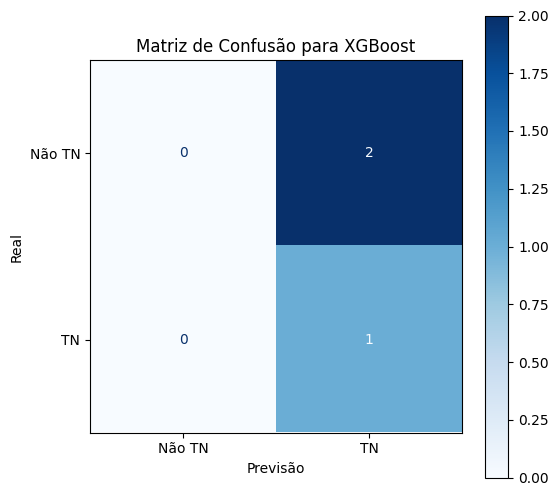

In [155]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcule a matriz de confusão
cm = confusion_matrix(y_teste, previsao_xgbost)

# Defina os rótulos das classes (se você souber, caso contrário, será 0, 1, 2...)
# Assumindo que as classes são 0 e 1, com base nos valores de 'TN' no seu df
class_names = ['Não TN', 'TN']

# Crie a visualização da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plote a matriz de confusão
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusão para XGBoost')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()
